本章主要内容：

# Where a trading idea meets the data — cross-asset momentum EDA

**Docker image**: `ml4t`

**Purpose**: Before we freeze a setup or fit a model, we test whether one concrete
idea — **cross-asset momentum** on the 100-ETF universe — actually leaves a
footprint in the data. This is the exploratory step that sits between a *story*
("recent winners keep winning") and a *strategy*. We use the single most
informative EDA tool in this domain: **sort by the signal, then look at forward
returns per bucket.**

## The idea and its mechanism

The idea: assets that went up over the past year tend to keep outperforming over
the next month, *across* asset classes (equities, sectors, countries, bonds,
commodities). Before any statistics, name the mechanism — *who is on the other
side, and why are they happy to trade with us?* This idea sits in the "behind"
family: we are betting others are slow or a step behind, not that we are paid to
bear a risk.

- **SLOW**: macro information diffuses across siloed markets with a lag; capital
  moves to the trend slowly. That gradual adjustment *is* the return.
- **WRONG**: investors under-react to news and chase performance, extending trends
  past fundamentals.

So this is a SLOW/WRONG blend. That also tells us the failure mode in advance:
momentum reverses sharply at turning points, and — because everyone can read the
same price history — the edge is the kind that **decays**. Keep that hypothesis in
mind; the data will have something to say about it.

## Learning objectives

- Build a monthly cross-sectional panel from the ETF daily data.
- Construct the classic **12-1 month momentum** signal (skip the most recent month).
- Run the **quintile conditional-return sort** and read it for *monotonicity,
  magnitude, and shape*.
- Stress the result by **era** — the difference between a footprint and an artifact.
- Leave with a measured verdict that motivates the rest of the chapter: freeze the
  setup, validate walk-forward, and respect costs and effective sample size.

**Book reference**: Chapter 6 §6.1–§6.2 (from idea to evidence; mapping strategies
and sources of edge); Chapter 7 (defining a tradable label and the conditional
feature–label relationship).

**Prerequisites**: `data` package on `PYTHONPATH`; ETF parquet present at
`ML4T_DATA_PATH/etfs/market/`. Run `python data/etfs/market/download.py` if missing.

In [24]:
"""Cross-asset momentum EDA — from a story to a measured footprint."""

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from data import load_etfs
from utils.style import COLORS, add_message_title

In [25]:
# Production defaults — Papermill injects overrides for CI
LOOKBACK = 12  # months of past return in the signal
SKIP = 1  # skip the most recent month (the "12-1" convention)
N_QUANTILES = 5  # quintiles
MIN_NAMES = 30  # minimum eligible ETFs in a month to include it

## 1. Build the monthly panel

The signal and the outcome both live at a **monthly** cadence: we rank the
universe once a month and hold for the next month. We take each ETF's last close
of the month. `close` from `load_etfs()` is split/dividend-adjusted, so simple
returns are total returns.

In [26]:
prices = load_etfs().select("timestamp", "symbol", "close")
monthly = (
    prices.sort("timestamp")
    .group_by_dynamic("timestamp", every="1mo", group_by="symbol")
    .agg(pl.col("close").last())
    .with_columns(pl.col("timestamp").dt.month_end())
    .sort(["symbol", "timestamp"])
)

n_days, n_symbols = prices["timestamp"].n_unique(), prices["symbol"].n_unique()
span = monthly["timestamp"]
print(f"Daily panel:   {n_days:>4} days x {n_symbols} ETFs")
print(f"Monthly panel: {span.n_unique():>4} months x {n_symbols} ETFs")
print(f"Span:          {span.min():%Y-%m} to {span.max():%Y-%m}")

Daily panel:   5031 days x 99 ETFs
Monthly panel:  240 months x 99 ETFs
Span:          2006-01 to 2025-12


## 2. The signal and the outcome

**Signal — 12-1 momentum**: the cumulative return from 12 months ago to *one month
ago*. Skipping the most recent month is deliberate: it sidesteps the short-term
reversal that contaminates a raw 12-month return (that reversal is a *different*
mechanism — liquidity provision — with the opposite sign).

**Outcome — forward 1-month return**: what we actually earn holding the next month.
Note the two clocks are already distinct: a 12-month **lookback** feeding a 1-month
**holding period**. Keeping them separate is a core discipline of the strategy
research framework (§6.3–§6.5).

In [27]:
monthly = monthly.with_columns(
    momentum=(pl.col("close").shift(SKIP) / pl.col("close").shift(LOOKBACK) - 1).over("symbol"),
    fwd_ret=(pl.col("close").shift(-1) / pl.col("close") - 1).over("symbol"),
)

## 3. The simplest test: sort into quintiles, look at forward returns

Each month we rank every eligible ETF by its momentum signal and split them into
five equal buckets (quintile 1 = worst past year, quintile 5 = best), form an
**equal-weight portfolio** of each bucket, and record its return over the *next*
month. If the mechanism has a footprint, the buckets should line up: higher past
momentum → higher forward return.

We report each bucket two ways:

- **Gross** — its raw forward return.
- **Net of the market** — the bucket minus the equal-weight universe that month
  (its *relative* performance). This strips out beta — the return you get just for
  being invested — and leaves the momentum *tilt*. Note this is net of the
  **benchmark**, not net of **trading costs**: we have not subtracted a basis point
  of cost anywhere in this notebook.

We are reading three things:

- **Monotonicity** — does the relationship order correctly across *all* buckets,
  not just top-vs-bottom?
- **Magnitude** — is the top-minus-bottom spread economically material?
- **Shape** — is the effect smooth (premium-like) or concentrated in the tails
  (event-like)?

In [28]:
# Eligible cross-section: both signal and outcome present, in months with >= MIN_NAMES
# names. Sorting by (timestamp, momentum, symbol) breaks any signal ties by symbol so the
# rank is stable; the quintile then replicates pandas' `qcut` on the rank via its
# quantile edges (1 + 0.2k(n-1)), so buckets stay balanced and no tie collapses one.
elig = (
    monthly.drop_nulls(["momentum", "fwd_ret"])
    .filter(pl.len().over("timestamp") >= MIN_NAMES)
    .sort(["timestamp", "momentum", "symbol"])
)
rank = pl.col("momentum").rank("ordinal").over("timestamp")
n_names = pl.len().over("timestamp")
quintile = pl.lit(1)
for k in (1, 2, 3, 4):
    quintile = quintile + (rank > 1 + 0.2 * k * (n_names - 1)).cast(pl.Int32)
elig = elig.with_columns(quintile=quintile)
qs = list(range(1, N_QUANTILES + 1))
print(f"Cross-sectional observations: {elig.height:,} over {elig['timestamp'].n_unique()} months")

Cross-sectional observations: 20,942 over 227 months


In [29]:
# Monthly equal-weight bucket portfolios and the equal-weight benchmark, then each averaged
# across months. We report at the native monthly horizon: the sort ranks once a month and
# holds for one month, so a monthly return is the honest unit. Annualizing a single-month
# cross-sectional sort by ^12 would assume the edge recurs every month — which the by-era
# split below shows it does not.
benchmark = elig.group_by("timestamp").agg(bench=pl.col("fwd_ret").mean())
buckets = elig.group_by(["timestamp", "quintile"]).agg(ret=pl.col("fwd_ret").mean())
wide = (
    buckets.pivot(values="ret", index="timestamp", on="quintile")
    .join(benchmark, on="timestamp")
    .sort("timestamp")
)

bench_pct = benchmark["bench"].mean() * 100  # %/month
gross = [wide[str(q)].mean() * 100 for q in qs]  # %/month, quintile 1..5
net_bps = [(wide[str(q)] - wide["bench"]).mean() * 1e4 for q in qs]  # bps/month, net of benchmark

print(f"\nBenchmark (equal-weight universe): {bench_pct:.2f}% / month")
print("Forward 1-month return by momentum quintile:")
print(
    pl.DataFrame(
        {
            "quintile": qs,
            "gross_%/mo": [round(g, 3) for g in gross],
            "net_bps/mo": [round(b, 1) for b in net_bps],
        }
    )
)

# The top-minus-bottom spread is identical gross or net — the benchmark cancels.
long_short = (wide["5"] - wide["1"]).drop_nulls()  # tradable Q5-Q1, dollar-neutral
spread_bps = net_bps[-1] - net_bps[0]
ls_t = long_short.mean() / long_short.std() * np.sqrt(long_short.len())
print(f"\nTop-minus-bottom spread: {spread_bps:.0f} bps / month (same gross or net)")
print(
    f"Tradable long-short (Q5-Q1): {long_short.mean() * 1e4:.0f} bps / month, "
    f"t = {ls_t:.2f} (n = {long_short.len()}) — before costs"
)


Benchmark (equal-weight universe): 0.61% / month
Forward 1-month return by momentum quintile:
shape: (5, 3)
┌──────────┬────────────┬────────────┐
│ quintile ┆ gross_%/mo ┆ net_bps/mo │
│ ---      ┆ ---        ┆ ---        │
│ i64      ┆ f64        ┆ f64        │
╞══════════╪════════════╪════════════╡
│ 1        ┆ 0.514      ┆ -10.0      │
│ 2        ┆ 0.485      ┆ -12.9      │
│ 3        ┆ 0.562      ┆ -5.1       │
│ 4        ┆ 0.732      ┆ 11.9       │
│ 5        ┆ 0.778      ┆ 16.4       │
└──────────┴────────────┴────────────┘

Top-minus-bottom spread: 26 bps / month (same gross or net)
Tradable long-short (Q5-Q1): 26 bps / month, t = 0.91 (n = 227) — before costs


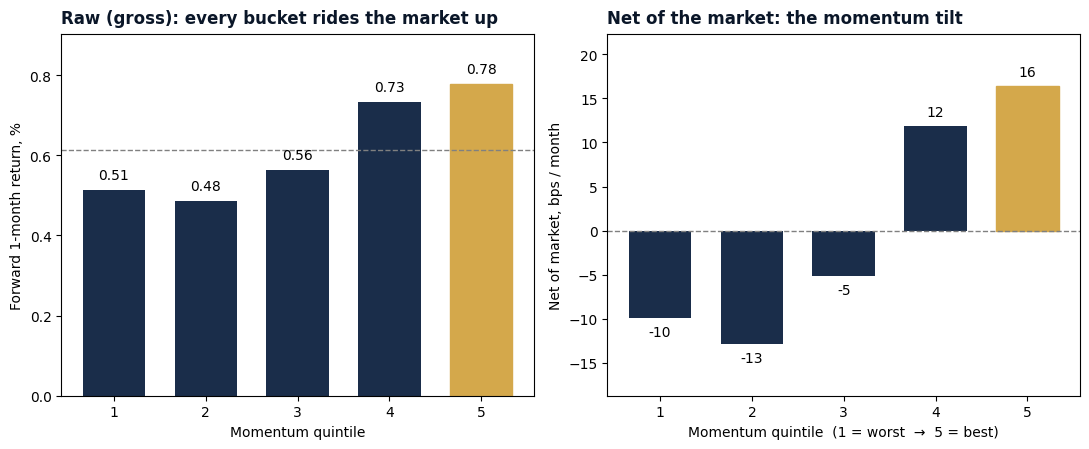

In [30]:
fig, (axg, axn) = plt.subplots(1, 2, figsize=(11, 4.6))
labels = [str(q) for q in qs]

bg = axg.bar(labels, gross, color=COLORS["slate"], width=0.68)
bg[-1].set_color(COLORS["amber"])
axg.axhline(bench_pct, ls="--", lw=1, color="grey")
add_message_title(axg, "Raw (gross): every bucket rides the market up")
axg.set_xlabel("Momentum quintile")
axg.set_ylabel("Forward 1-month return, %")
for x, v in zip(labels, gross):
    axg.text(x, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
axg.margins(y=0.16)

bn = axn.bar(labels, net_bps, color=COLORS["slate"], width=0.68)
bn[-1].set_color(COLORS["amber"])
axn.axhline(0, ls="--", lw=1, color="grey")
add_message_title(axn, "Net of the market: the momentum tilt")
axn.set_xlabel("Momentum quintile  (1 = worst  →  5 = best)")
axn.set_ylabel("Net of market, bps / month")
for x, v in zip(labels, net_bps):
    axn.text(
        x,
        v + (0.8 if v >= 0 else -0.8),
        f"{v:.0f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=10,
    )
axn.margins(y=0.20)
fig.tight_layout()
plt.show()

**Read it.** In raw (gross) terms every bucket earns 0.5–0.8% a month — but that is
mostly beta: they all sit around the dashed benchmark line, because the whole
universe drifted up. Strip the market out (right panel) and what is left is the
*tilt*: the bottom buckets are slightly negative, the top two slightly positive,
ordering roughly with past momentum. The spread from worst to best is the same
either way (~26 bps a month) — the benchmark cancels — and it is **modest**. The
tradable long-short is thin (t ≈ 0.9, before costs). On the full sample this looks
like a small footprint; a single average can still hide a lot, so we stress it by era.

## 4. Is it lumpy but present, or an artifact? Split by era

A real mechanism is usually *lumpy but present* — it survives being cut by time,
even if it isn't equally strong everywhere. An effect that lives entirely in one
period is telling you what it actually is. We split the sample in half and rerun
the sort. Recall the mechanism's own warning: information-based edges **decay** as
everyone learns to read the same price history.

In [31]:
wide_era = wide.with_columns(
    era=pl.when(pl.col("timestamp") < pl.date(2016, 1, 1))
    .then(pl.lit("2006–2015"))
    .otherwise(pl.lit("2016–2025"))
)
rows = []
for era in ["2006–2015", "2016–2025"]:
    e = wide_era.filter(pl.col("era") == era)
    q1 = (e["1"] - e["bench"]).mean() * 1e4
    q5 = (e["5"] - e["bench"]).mean() * 1e4
    ls_e = (e["5"] - e["1"]).drop_nulls()
    rows.append(
        {
            "era": era,
            "Q1_net_bps": round(q1),
            "Q5_net_bps": round(q5),
            "spread_bps": round(q5 - q1),
            "ls_t": round(ls_e.mean() / ls_e.std() * np.sqrt(ls_e.len()), 2),
            "months": e.height,
        }
    )
era_tbl = pl.DataFrame(rows)
print(era_tbl)

shape: (2, 6)
┌───────────┬────────────┬────────────┬────────────┬──────┬────────┐
│ era       ┆ Q1_net_bps ┆ Q5_net_bps ┆ spread_bps ┆ ls_t ┆ months │
│ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---  ┆ ---    │
│ str       ┆ i64        ┆ i64        ┆ i64        ┆ f64  ┆ i64    │
╞═══════════╪════════════╪════════════╪════════════╪══════╪════════╡
│ 2006–2015 ┆ -24        ┆ 18         ┆ 42         ┆ 0.86 ┆ 108    │
│ 2016–2025 ┆ 3          ┆ 15         ┆ 12         ┆ 0.37 ┆ 119    │
└───────────┴────────────┴────────────┴────────────┴──────┴────────┘


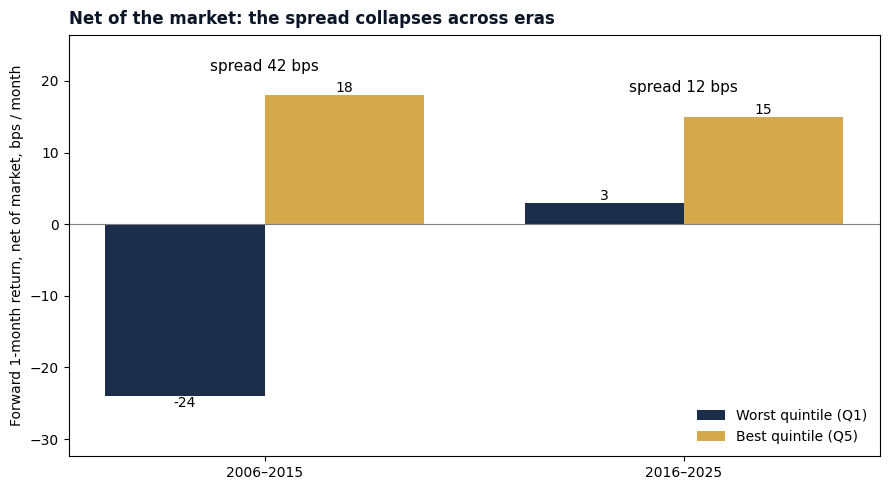

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
eras = era_tbl["era"].to_list()
q1_bps, q5_bps, spreads = (
    era_tbl["Q1_net_bps"].to_list(),
    era_tbl["Q5_net_bps"].to_list(),
    era_tbl["spread_bps"].to_list(),
)
x = np.arange(len(eras))
w = 0.38
ax.bar(x - w / 2, q1_bps, w, label="Worst quintile (Q1)", color=COLORS["slate"])
ax.bar(x + w / 2, q5_bps, w, label="Best quintile (Q5)", color=COLORS["amber"])
for xi, (q1, q5, sp) in enumerate(zip(q1_bps, q5_bps, spreads)):
    ax.text(
        xi - w / 2, q1, f"{q1:.0f}", ha="center", va="bottom" if q1 >= 0 else "top", fontsize=10
    )
    ax.text(
        xi + w / 2, q5, f"{q5:.0f}", ha="center", va="bottom" if q5 >= 0 else "top", fontsize=10
    )
    ax.text(xi, max(q1, q5) + 3, f"spread {sp:.0f} bps", ha="center", va="bottom", fontsize=11)
ax.axhline(0, lw=0.8, color="grey")
ax.set_xticks(x)
ax.set_xticklabels(eras)
ax.set_ylabel("Forward 1-month return, net of market, bps / month")
add_message_title(ax, "Net of the market: the spread collapses across eras")
ax.legend(frameon=False, loc="lower right")
ax.margins(y=0.2)
fig.tight_layout()
plt.show()

**Read it.** Net of the market, the tilt is clear in the first decade (a wide
Q5-over-Q1 gap) and much smaller in the second — the spread falls to roughly a fifth
of its first-decade level (about 45 bps to about 9 bps a month).
That is consistent with an information-based edge decaying as it becomes widely
known. Two cautions keep this at "suggestive," not "proven": the tradable
long-short is not statistically significant in either era (see `ls_t`), and a
two-bucket split is itself a coarse cut — the exercises push you to move the
boundary and watch how stable the fade really is.

## 5. One feasibility check: how fast does the signal turn over?

Costs are decided by turnover, and turnover is governed by how much the ranking
changes month to month. We measure the month-over-month rank autocorrelation of
the signal: high autocorrelation means today's winners are mostly last month's
winners, so we trade little.

In [33]:
# Spearman rank correlation = Pearson correlation of the ranks. For each pair of adjacent
# months we join on the symbols present in both, require >= MIN_NAMES, and average the
# per-pair correlations.
mom = monthly.select("timestamp", "symbol", "momentum").drop_nulls("momentum")
months = mom["timestamp"].unique().sort().to_list()
month_index = {t: i for i, t in enumerate(months)}
mom = mom.with_columns(mi=pl.col("timestamp").replace_strict(month_index, return_dtype=pl.Int32))
this_month = mom.select("symbol", "momentum", "mi")
prev_month = mom.select(
    "symbol", pl.col("momentum").alias("mom_prev"), (pl.col("mi") + 1).alias("mi")
)
pairs = (
    this_month.join(prev_month, on=["symbol", "mi"])
    .filter(pl.len().over("mi") >= MIN_NAMES)
    .with_columns(
        r_curr=pl.col("momentum").rank("average").over("mi"),
        r_prev=pl.col("mom_prev").rank("average").over("mi"),
    )
)
autocorr = pairs.group_by("mi").agg(rho=pl.corr("r_curr", "r_prev"))["rho"].mean()
print(f"Mean month-over-month rank autocorrelation: {autocorr:.3f}")
print("(High → the ranking is persistent → turnover and costs are modest.)")

Mean month-over-month rank autocorrelation: 0.894
(High → the ranking is persistent → turnover and costs are modest.)


## 6. Verdict — and what comes next

What the EDA established, and what it did **not**:

- Net of the market, the mechanism leaves a **modest, top-concentrated** tilt —
  enough to be worth engineering, not enough to trade on its own. The tradable
  long-short is thin and **not statistically significant** (t ≈ 0.9), and all of
  this is **before costs**.
- It is **regime-dependent**: the spread collapses from about 45 bps a month in
  2006–2015 to about 9 bps in 2016–2025. Evaluation must respect *when* the edge lived, which is why we validate
  **walk-forward**, not on a shuffled or full-sample average.
- The signal is **persistent** (low turnover), so costs are unlikely to erase it
  outright — but again, we have not yet subtracted a single basis point.

Nothing here is a backtest. It is visual confirmation that there is *something* to
model, plus a set of cautions. The rest of the chapter turns this into a disciplined
evaluation: **freeze the setup** (§6.3), **validate it walk-forward without leakage**
(§6.5), and keep the search **countable and auditable** (§6.7). Chapter 7 then
defines a **tradable label** and accounts for **overlap and effective sample size**
before trusting any significance.